# CAER-S – 4-Class Emotion Classification (v7)

Real images only. Stable training pipeline.

**Emotion clusters:**
| ID | Label | Source emotions |
|----|-------|-----------------|
| 0 | Optimistic  | Happy |
| 1 | Pessimistic | Sadness + Fear             |
| 2 | Hostile     | Anger + Disgust            |
| 3 | Neutral     | Neutral |

**Changes in v7 vs v6:**
- CrossEntropyLoss restored (focal loss removed — too many interacting failure modes
  with MixUp and an unstable backbone at unfreeze time)
- Backbone LR reduced 10× (`5e-6 → 5e-7`) to prevent catastrophic forgetting
- Phase 2 split into two sub-phases:
  - **2a**: head-only training at full `lr_head_ft` for 2 epochs after MixUp enabled
  - **2b**: full unfreeze with very conservative backbone LR + cosine schedule
- MixUp disabled for the first unfrozen epoch to let the head stabilise
- Focal loss kept as an optional drop-in (commented out) for after convergence


## 1. Config

Config is meant to be a single source of truth.

In [1]:
from dataclasses import dataclass
import torch


@dataclass
class Config:
    # --- data ---
    data_csv:    str = "/home/simon/Documents/Zwischen Wörtern und Pixeln/annotations-caer_cleaned_4cluster.csv"
    image_col:   str = "image_path"
    label_col:   str = "emotion_recode2"   # 0=Optimistic 1=Pessimistic 2=Hostile 3=Neutral
    num_classes: int = 4
    img_size:    int = 224
    val_ratio:  float = 0.2
    random_seed: int = 42

    # --- model ---
    model_name:     str   = "swin_base_patch4_window7_224"
    pretrained:     bool  = True
    drop_rate:     float  = 0.3    # dropout before the classification head
    drop_path_rate: float = 0.1    # stochastic depth, enabled at Phase 2b only
    batch_size: int = 64

    # --- training phases ---
    # Phase 1  : backbone frozen, head only, no MixUp
    epochs_frozen:   int   = 3
    lr_head:        float  = 1e-4

    # Phase 2a : backbone still frozen, MixUp enabled, head consolidates
    epochs_head:     int   = 2
    lr_head_warmup: float  = 5e-5   # slightly lower than Phase 1 for stability

    # Phase 2b : full fine-tune, conservative backbone LR
    epochs_finetune: int   = 30     # early stopping will cut this short
    lr_backbone:    float  = 5e-6   
    lr_head_ft:     float  = 2e-5

    weight_decay:   float  = 1e-4
    grad_clip:      float  = 1.0

    # --- MixUp ---
    # Disabled in Phase 1 and first epoch of Phase 2b.
    # Enabled in Phase 2a onward.
    mixup_alpha: float = 0.2

    # --- early stopping ---
    patience: int = 7

    # --- system ---
    num_workers: int = 8
    device:      str = "cuda"

#additional definitions
cfg = Config()
cfg.device = torch.device(cfg.device)

#classes
EMOTION_NAMES = ["Optimistic", "Pessimistic", "Hostile", "Neutral"]

#verify
print("Config ready. Device:", cfg.device)
print("Classes:", EMOTION_NAMES)
print(f"Total epochs (max): {cfg.epochs_frozen} + {cfg.epochs_head} + {cfg.epochs_finetune} = "
      f"{cfg.epochs_frozen + cfg.epochs_head + cfg.epochs_finetune}")


Config ready. Device: cuda
Classes: ['Optimistic', 'Pessimistic', 'Hostile', 'Neutral']
Total epochs (max): 3 + 2 + 30 = 35


## 2. Data Utilities

We define the following functions:
- `stratified_split`: Conducts a stratified split into train and validation datasets according to split ratio defined in config.

- `compute_class_weights`: Computes class weights by sqrt. inverse-frequency. Produces a scalar which is later passed to the CrossEntropyLoss criterion.

- `build_sampler`: Introduces a weighted random sampler to have a roughly balanced batch distribution during training.

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from torch.utils.data import WeightedRandomSampler


def stratified_split(cfg):
    """Stratified 80/20 split. Casts float CSV labels to int."""
    df = pd.read_csv(cfg.data_csv, 
                     low_memory = False) #read entire file before inferring types
    
    #force integer
    df[cfg.label_col] = df[cfg.label_col].astype(int)

    assert set(df[cfg.label_col].unique()) <= {0, 1, 2, 3}, \
        f"Unexpected label values: {sorted(df[cfg.label_col].unique())}"

    train_df, val_df = train_test_split(
        df,
        test_size    = cfg.val_ratio, #use split ratio from config
        stratify     = df[cfg.label_col], #stratify by class
        random_state = cfg.random_seed, #use seed from config
    )
    return train_df.reset_index(drop =  True), val_df.reset_index(drop = True)


def compute_class_weights(train_df, 
                          cfg):
    
    """Sqrt inverse-frequency weights, normalised to mean = 1.
    Later passed to CrossEntropyLoss criterion.
    """
    counts  = train_df[cfg.label_col].value_counts().sort_index()
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.sum() * cfg.num_classes
    return torch.tensor(weights.values, dtype = torch.double) #fp64 precision


def build_sampler(train_df, 
                  cfg):
    
    """WeightedRandomSampler for roughly balanced training batches."""
    counts         = train_df[cfg.label_col].value_counts().to_dict()
    sample_weights = train_df[cfg.label_col].map(lambda c: 1.0 / counts[c])
    return WeightedRandomSampler(
        weights     = torch.tensor(sample_weights.values, dtype = torch.double), #fp64 precision
        num_samples = len(sample_weights),
        replacement = True,
    )


# ---- run ----
train_df, val_df = stratified_split(cfg)
class_weights    = compute_class_weights(train_df, cfg).to(cfg.device)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}")

print("Class weights:",
      {EMOTION_NAMES[i]: f"{class_weights[i].item():.3f}" for i in range(cfg.num_classes)})

print("\nTrain distribution:")

print(train_df[cfg.label_col].value_counts().sort_index()
      .rename(index = dict(enumerate(EMOTION_NAMES))).to_string())

print("\nVal distribution:")

print(val_df[cfg.label_col].value_counts().sort_index()
      .rename(index = dict(enumerate(EMOTION_NAMES))).to_string())


Train: 48000  |  Val: 12000
Class weights: {'Optimistic': '1.172', 'Pessimistic': '0.828', 'Hostile': '0.828', 'Neutral': '1.172'}

Train distribution:
emotion_recode2
Optimistic      8000
Pessimistic    16000
Hostile        16000
Neutral         8000

Val distribution:
emotion_recode2
Optimistic     2000
Pessimistic    4000
Hostile        4000
Neutral        2000


## 3. Transforms

We apply transformations to our images. Standard ImageNet normalisations are applied to all images. <br><br>
Additionally, these transforms are applied to the training split:
- Random Crop
- Horizontal flip
- Brightness & Contrast
- HSV (Hue, Saturation & Value)
- Rotate
- Gaussian Noise
- Coarse Dropout

In [3]:
import cv2
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader

#ImageNet normalisations
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)


def get_transforms(cfg, train = True):
    """Return albumentations pipeline.

      - Random Crop
      - Horizontal flip (p = 0.5)
      - Brightness/Contrast (p = 0.5)
      - HSV (p = 0.3)
      - Rotate (p = 0.5)
      - GaussNoise (p = 0.3) — simulates image quality variation
      - CoarseDropout (p = 0.5)

    Validation: only resize + normalise. No stochastic ops.
    """
    norm = A.Normalize(mean = IMAGENET_MEAN, std = IMAGENET_STD)

    if train:
        return A.Compose([
            A.RandomResizedCrop(size = (cfg.img_size, cfg.img_size), scale = (0.75, 1.0)),
            A.HorizontalFlip(p = 0.5),
            A.RandomBrightnessContrast(brightness_limit = 0.3, contrast_limit = 0.3, p = 0.5),
            A.HueSaturationValue(hue_shift_limit = 10, sat_shift_limit = 20, val_shift_limit = 10, p = 0.3),
            A.Rotate(limit = 15, p = 0.5),
            A.GaussNoise(p = 0.3),
            A.CoarseDropout(max_holes = 1, max_height = 48, max_width = 48,
                            min_holes = 1, min_height = 16, min_width = 16, p = 0.5),
            norm,
            ToTensorV2(),
        ])
    else:
        return A.Compose([
            A.Resize(cfg.img_size, cfg.img_size),
            norm,
            ToTensorV2(),
        ])


class EmotionDataset(Dataset):
    """Loads images with OpenCV, applies albumentations transforms.

    Returns (image_tensor, label) where label is an int in [0, num_classes).
    """

    def __init__(self, 
                 df, 
                 cfg, 
                 transform = None):
        
        self.df        = df.reset_index(drop = True)
        self.transform = transform
        self.image_col = cfg.image_col
        self.label_col = cfg.label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, 
                    idx):
        
        row   = self.df.iloc[idx]
        image = cv2.imread(row[self.image_col])
        if image is None:
            raise FileNotFoundError(f"Image not found: {row[self.image_col]}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        if self.transform:
            image = self.transform(image = image)["image"]
        return image, int(row[self.label_col])


# ---- build datasets & loaders ----
train_ds = EmotionDataset(train_df, cfg, transform = get_transforms(cfg, train = True))
val_ds   = EmotionDataset(val_df,   cfg, transform = get_transforms(cfg, train = False))

train_sampler = build_sampler(train_df, cfg)

train_loader = DataLoader(
    train_ds,
    batch_size  = cfg.batch_size,
    sampler     = train_sampler,
    num_workers = cfg.num_workers,
    pin_memory  = True,
)
val_loader = DataLoader(
    val_ds,
    batch_size  = cfg.batch_size,
    shuffle     = False,
    num_workers = cfg.num_workers,
    pin_memory  = True,
)

#verify
imgs, labels = next(iter(train_loader))
print("Batch image shape :", imgs.shape)
print("Batch label shape :", labels.shape)
print("Label dtype        :", labels.dtype)
print("Pixel min/max      :", round(imgs.min().item(), 3), round(imgs.max().item(), 3))
assert imgs.shape[1:] == (3, cfg.img_size, cfg.img_size)
assert labels.dtype == torch.long
print("Sanity check passed.")


/tmp/ipykernel_16720/2300854325.py:30: UserWarning: Argument(s) 'max_holes, max_height, max_width, min_holes, min_height, min_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=1, max_height=48, max_width=48,


Batch image shape : torch.Size([64, 3, 224, 224])
Batch label shape : torch.Size([64])
Label dtype        : torch.int64
Pixel min/max      : -2.118 2.64
Sanity check passed.


## 4. Model

We define the following functions:
- `build model`: Define model params.
  
- `init_head`: Reinitialise classification head. Use neutral weights.

- `get_head_param_prefix`: Function is defined as some models carry a `head` prefix and others a `head.fc` prefix.

- `check_pred_distribution`: Safeguard function to catch catastrophic distribution failure. Checks if head bias is being initialised to a large non-zero value, making one class's logit dramatically higher than the others before any training.

- `enable_drop_path`: Randomly drops features to prevent overfitting.

- `freeze_backbone`: Freeze backbone and train only on classification head.

- `unfreeze_backbone`: Train all parameters.


In [4]:
import timm
import collections
import torch.nn as nn


def build_model(cfg):
    """Create DeiT-Base. drop_path disabled until Phase 2b."""
    model = timm.create_model(
        cfg.model_name,
        pretrained     = cfg.pretrained,
        num_classes    = cfg.num_classes,
        drop_rate      = cfg.drop_rate,
        drop_path_rate = 0.0,
    )
    return model


def init_head(model):
    """Reinitialise classification head with neutral weights."""
    linear = model.head.fc
    torch.nn.init.trunc_normal_(linear.weight, std = 0.02)
    torch.nn.init.zeros_(linear.bias)
    print("Head reinitialised.")

def get_head_param_prefix(model):
    """Return the parameter name prefix for the classification head."""
    if isinstance(model.head, torch.nn.Linear):
        return "head"
    elif hasattr(model.head, "fc"):
        return "head"   # Swin's full head (including pooling) starts with 'head'
    else:
        raise AttributeError(f"Unknown head type: {type(model.head).__name__}")


def check_pred_distribution(model, 
                            loader, 
                            cfg, 
                            label = ""):
    
    """Verify model predicts all classes before training starts."""
    
    model.eval()
    
    all_preds = []
    with torch.no_grad():
        for images, _ in loader:
            preds = model(images.to(cfg.device)).argmax(dim = 1)
            all_preds.extend(preds.cpu().tolist())
    counts = dict(sorted(collections.Counter(all_preds).items()))
    total  = len(all_preds)
    pct    = {EMOTION_NAMES[k]: f"{v/total*100:.1f}%" for k, v in counts.items()}
    print(f"Pred distribution {label}: {pct}")
    dominant = max(counts.values()) / total
    if dominant > 0.8:
        print("WARNING: one class dominates — check head initialisation before training.")
    return counts


def enable_drop_path(model, 
                     rate):
    
    """Enable stochastic depth on all DropPath modules."""
    from timm.layers import DropPath
    count = 0
    for module in model.modules():
        if isinstance(module, DropPath):
            module.drop_prob = rate
            count += 1
    print(f"drop_path_rate set to {rate} on {count} DropPath modules.")


def freeze_backbone(model):
    """Freeze everything except the classification head."""
    prefix = get_head_param_prefix(model)
    for name, p in model.named_parameters():
        p.requires_grad = name.startswith(prefix)
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Backbone frozen. Trainable: {n:,}")


def unfreeze_backbone(model, 
                      cfg):
    
    """Unfreeze all params and return AdamW with differential LRs."""
    prefix = get_head_param_prefix(model)
    for p in model.parameters():
        p.requires_grad = True
    n = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Backbone unfrozen. Trainable: {n:,}")

    optimizer = torch.optim.AdamW([
        {"params": [p for name, p in model.named_parameters()
                    if not name.startswith(prefix)], "lr": cfg.lr_backbone},
        {"params": [p for name, p in model.named_parameters()
                    if name.startswith(prefix)],     "lr": cfg.lr_head_ft},
    ], weight_decay = cfg.weight_decay, betas = (0.9, 0.999))
    return optimizer


# ---- build & verify ----
model = build_model(cfg).to(cfg.device)
init_head(model)

total = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Model: {cfg.model_name}  |  {total:.1f} M params")
check_pred_distribution(model, val_loader, cfg, label="(after init)")


Head reinitialised (ClassifierHead → Linear).
Model: swin_base_patch4_window7_224  |  86.7 M params
Pred distribution (after init): {'Optimistic': '5.5%', 'Pessimistic': '19.4%', 'Hostile': '68.4%', 'Neutral': '6.7%'}


{0: 655, 1: 2330, 2: 8209, 3: 806}

<br><br><br>
> **Note:** Pred distribution after init might look unbalanced, but is usually just expected random variation from weight initialisation. The weights are small but not zero. `trunc_normal_(std = 0.02)` gives weights centred on zero with a tiny spread. The dot product of those small random weights with the backbone's output features produces logits that are close to zero but not identical across classes. Small random differences get amplified by softmax into apparently large probability differences even when the underlying logits are nearly equal. <br><br>
> Note that the pred distribution function only exists to catch **catastrophic distribution failure** in which case a warning message is printed. 

<br><br><br>

## 5. Training & Validation

We define the following functions:
- `mixup_batch`: MixUp allows for the creation of soft labels. If `alpha` is zero, hard labels are used. Validation always uses hard labels.

- `train_one_epoch`: Defines a single training pass. MixUp is passed explicitly, so it can be disabled if needed. This way we do not need to change our config.

- `validate`: Returns metrics like vlaidation loss (needed for early stopping), accuracy, precision, recall and f1. Also returns per-class metrics.

- `log_epoch`: Logs performnace metrics in history object.

In [5]:
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report


def mixup_batch(images, 
                labels, 
                alpha, 
                num_classes, 
                device):
    
    """MixUp: blend image pairs and their one-hot labels.
    Returns (mixed_images, soft_labels). When alpha = 0 returns hard one-hot labels.
    """
    if alpha <= 0.0:
        return images, F.one_hot(labels, num_classes).float()
    lam          = np.random.beta(alpha, alpha)
    idx          = torch.randperm(images.size(0), device = device)
    mixed_images = lam * images + (1 - lam) * images[idx]
    onehot       = F.one_hot(labels, num_classes).float()
    mixed_labels = lam * onehot + (1 - lam) * onehot[idx]
    return mixed_images, mixed_labels


def train_one_epoch(model, 
                    loader, 
                    optimizer, 
                    criterion, 
                    cfg, 
                    scaler, 
                    mixup_alpha = 0.0):
    
    """One training pass.

    mixup_alpha is passed explicitly so the main loop can disable it
    for specific epochs (e.g. first unfrozen epoch) without touching cfg.
    """
    model.train()
    total_loss = 0.0

    for images, labels in tqdm(loader, leave = False):
        images = images.to(cfg.device)
        labels = labels.to(cfg.device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            if mixup_alpha > 0.0:
                images, soft_labels = mixup_batch(
                    images, labels, mixup_alpha, cfg.num_classes, cfg.device
                )
                outputs = model(images)
                # CrossEntropyLoss accepts soft (float) 2-D label tensors directly
                loss = criterion(outputs, soft_labels)
            else:
                outputs = model(images)
                loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, 
             loader, 
             criterion, 
             cfg):
    
    """Evaluate on the validation set with hard labels.

    Returns val_loss, val_acc, macro_f1, per_class_loss, report.
    val_loss is used for early stopping and model selection.
    macro_f1 is the primary performance metric for imbalanced classes.
    """
    model.eval()
    
    total_loss     = 0.0
    all_preds      = []
    all_labels     = []
    class_loss_sum = torch.zeros(cfg.num_classes)
    class_loss_cnt = torch.zeros(cfg.num_classes)

    for images, labels in loader:
        images = images.to(cfg.device)
        labels = labels.to(cfg.device)

        outputs = model(images)
        loss    = F.cross_entropy(outputs, labels, weight = criterion.weight)
        preds   = outputs.argmax(dim=1)

        total_loss += loss.item()
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        for c in range(cfg.num_classes):
            mask = labels == c
            if mask.any():
                class_loss_sum[c] += F.cross_entropy(
                    outputs[mask], labels[mask], weight=criterion.weight
                ).item()
                class_loss_cnt[c] += 1

    val_loss       = total_loss / len(loader)
    val_acc        = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    macro_f1       = f1_score(all_labels, all_preds, average = "macro")
    per_class_loss = (class_loss_sum / class_loss_cnt.clamp(min = 1)).tolist()
    report         = classification_report(
        all_labels, all_preds,
        target_names = EMOTION_NAMES,
        digits       = 3,
    )
    return val_loss, val_acc, macro_f1, per_class_loss, report


def log_epoch(tag, 
              epoch, 
              total, 
              train_loss, 
              val_loss, 
              val_acc, 
              macro_f1,
              per_class_loss, 
              history):
    
    """Print epoch summary and append to history list."""
    pcl = {EMOTION_NAMES[i]: f"{per_class_loss[i]:.3f}" for i in range(len(per_class_loss))}
    phase_num = 1 if tag == "P1" else 2
    history.append(dict(phase = phase_num, tag = tag, epoch = epoch,
                        train_loss = train_loss, val_loss = val_loss,
                        val_acc = val_acc, macro_f1 = macro_f1))
    print(f"[{tag}] Epoch {epoch + 1:02d}/{total} | "
          f"train={train_loss:.4f} | "
          f"val={val_loss:.4f} | "
          f"acc={val_acc:.4f} | "
          f"F1={macro_f1:.4f}")
    print(f"       per-class loss: {pcl}")


## 6. Main Training Script

Three phases:

| Phase | Backbone | MixUp | Purpose |
|-------|----------|-------|---------|
| 1 | Frozen | Off | Head learns from stable features |
| 2a | Frozen | On | Head consolidates with augmentation |
| 2b | Unfrozen | Off→On | Full fine-tune, very low backbone LR |

Early stopping in Phase 2b only (patience = 7). <br>
Best checkpoint saved on `val_loss` throughout.

In [6]:
import torch
from torch.optim.lr_scheduler import CosineAnnealingLR

torch.manual_seed(cfg.random_seed)

# CrossEntropyLoss with sqrt class weights.
# Accepts both hard (long) and soft (float 2-D) label tensors.
criterion = torch.nn.CrossEntropyLoss(
    weight    = class_weights,
    reduction = "mean",
)

scaler        = torch.amp.GradScaler("cuda")
history       = []
best_val_loss = float("inf")
best_macro_f1 = 0.0


# =========================================================================
# PHASE 1 — frozen backbone, no MixUp
# Goal: head learns to separate the 4 classes from frozen backbone features.
# =========================================================================
freeze_backbone(model)

optimizer_p1 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr = cfg.lr_head, weight_decay = cfg.weight_decay, betas = (0.9, 0.999),
)
scheduler_p1 = CosineAnnealingLR(optimizer_p1, T_max=cfg.epochs_frozen)
total_p1     = cfg.epochs_frozen

print("=" * 65)
print("PHASE 1 — frozen backbone, no MixUp")
print("=" * 65)

for epoch in range(cfg.epochs_frozen):
    train_loss = train_one_epoch(
        model, train_loader, optimizer_p1, criterion, cfg, scaler, mixup_alpha = 0.0
    )
    val_loss, val_acc, macro_f1, pcl, report = validate(model, val_loader, criterion, cfg)
    scheduler_p1.step()
    log_epoch("P1", epoch, total_p1, train_loss, val_loss, val_acc, macro_f1, pcl, history)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_macro_f1 = macro_f1
        torch.save(model.state_dict(), "best_model_swin.pth")
        print("best saved")

print()
print(report)


# =========================================================================
# PHASE 2a — backbone still frozen, MixUp enabled
# Goal: head consolidates with augmented signal before backbone is touched.
# =========================================================================
# Keep backbone frozen; only update head LR
optimizer_p2a = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr = cfg.lr_head_warmup, weight_decay = cfg.weight_decay, betas = (0.9, 0.999),
)
scheduler_p2a = CosineAnnealingLR(optimizer_p2a, T_max = cfg.epochs_head)
total_p2a     = cfg.epochs_frozen + cfg.epochs_head

print("=" * 65)
print(f"PHASE 2a — backbone still frozen, MixUp enabled (alpha = {cfg.mixup_alpha})")
print("=" * 65)

for epoch in range(cfg.epochs_head):
    global_epoch = cfg.epochs_frozen + epoch
    train_loss = train_one_epoch(
        model, train_loader, optimizer_p2a, criterion, cfg, scaler,
        mixup_alpha = cfg.mixup_alpha
    )
    val_loss, val_acc, macro_f1, pcl, report = validate(model, val_loader, criterion, cfg)
    scheduler_p2a.step()
    log_epoch("P2a", global_epoch, total_p2a, train_loss, val_loss, val_acc, macro_f1, pcl, history)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_macro_f1 = macro_f1
        torch.save(model.state_dict(), "best_model_swin.pth")
        print("best saved")


# =========================================================================
# PHASE 2b — full unfreeze, conservative backbone LR, early stopping
# First epoch: no MixUp (let head re-adapt to shifting backbone features).
# From epoch 2 onward: MixUp re-enabled.
# =========================================================================
enable_drop_path(model, cfg.drop_path_rate)
optimizer_p2b = unfreeze_backbone(model, cfg)
scheduler_p2b = CosineAnnealingLR(optimizer_p2b, T_max = cfg.epochs_finetune)

epochs_no_improve = 0
total_p2b         = cfg.epochs_frozen + cfg.epochs_head + cfg.epochs_finetune

print()
print("=" * 65)
print("PHASE 2b — full fine-tune")
print(f"  backbone lr = {cfg.lr_backbone}  head lr = {cfg.lr_head_ft}")
print(f"  drop_path = {cfg.drop_path_rate}  patience = {cfg.patience}")
print("  epoch 1: MixUp OFF  |  epoch 2+: MixUp ON")
print("=" * 65)

for epoch in range(cfg.epochs_finetune):
    global_epoch = cfg.epochs_frozen + cfg.epochs_head + epoch

    # MixUp off for first unfrozen epoch — head needs one stable step
    # to adapt to the shifting backbone features before labels are added
    mixup_this_epoch = 0.0 if epoch == 0 else cfg.mixup_alpha

    train_loss = train_one_epoch(
        model, train_loader, optimizer_p2b, criterion, cfg, scaler,
        mixup_alpha = mixup_this_epoch
    )
    val_loss, val_acc, macro_f1, pcl, report = validate(model, val_loader, criterion, cfg)
    scheduler_p2b.step()

    mixup_tag = f"mixup={'off' if mixup_this_epoch == 0 else 'on'}"
    log_epoch(f"P2b({mixup_tag})", global_epoch, total_p2b,
              train_loss, val_loss, val_acc, macro_f1, pcl, history)

    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        best_macro_f1     = macro_f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_model_swin.pth")
        print("best saved")
    else:
        epochs_no_improve += 1
        print(f"  no improvement ({epochs_no_improve}/{cfg.patience})")
        if epochs_no_improve >= cfg.patience:
            print(f"  Early stopping at epoch {global_epoch+1}.")
            break

    if (epoch + 1) % 5 == 0:
        print()
        print(report)

print()
print(f"Training complete.")
print(f"Best val_loss: {best_val_loss:.4f}  |  Best macro_f1: {best_macro_f1:.4f}")


Backbone frozen. Trainable: 4,100
PHASE 1 — frozen backbone, no MixUp


[P1] Epoch 01/3 | train=1.3532 | val=1.3215 | acc=0.3572 | F1=0.3541
       per-class loss: {'Optimistic': '1.135', 'Pessimistic': '1.399', 'Hostile': '1.521', 'Neutral': '1.116'}
  → best saved


[P1] Epoch 02/3 | train=1.2917 | val=1.2888 | acc=0.3802 | F1=0.3819
       per-class loss: {'Optimistic': '1.129', 'Pessimistic': '1.469', 'Hostile': '1.385', 'Neutral': '1.057'}
  → best saved


[P1] Epoch 03/3 | train=1.2723 | val=1.2723 | acc=0.3917 | F1=0.3926
       per-class loss: {'Optimistic': '1.112', 'Pessimistic': '1.395', 'Hostile': '1.388', 'Neutral': '1.094'}
  → best saved

              precision    recall  f1-score   support

  Optimistic      0.346     0.578     0.432      2000
 Pessimistic      0.559     0.334     0.418      4000
     Hostile      0.525     0.257     0.345      4000
     Neutral      0.274     0.592     0.375      2000

    accuracy                          0.392     12000
   macro avg      0.426     0.440     0.393     12000
weighted avg      0.465     0.392     0.389     12000

PHASE 2a — backbone still frozen, MixUp enabled (alpha=0.2)


[P2a] Epoch 04/5 | train=1.2874 | val=1.2830 | acc=0.3748 | F1=0.3741
       per-class loss: {'Optimistic': '1.037', 'Pessimistic': '1.461', 'Hostile': '1.449', 'Neutral': '1.041'}


...

[P2b(mixup=on)] Epoch 31/35 | train=0.6363 | val=0.4390 | acc=0.8383 | F1=0.8236
       per-class loss: {'Optimistic': '0.487', 'Pessimistic': '0.389', 'Hostile': '0.399', 'Neutral': '0.513'}
  no improvement (2/7)


[P2b(mixup=on)] Epoch 32/35 | train=0.6190 | val=0.4292 | acc=0.8442 | F1=0.8291
       per-class loss: {'Optimistic': '0.434', 'Pessimistic': '0.352', 'Hostile': '0.396', 'Neutral': '0.575'}
  → best saved


[P2b(mixup=on)] Epoch 33/35 | train=0.6337 | val=0.4367 | acc=0.8391 | F1=0.8245
       per-class loss: {'Optimistic': '0.449', 'Pessimistic': '0.387', 'Hostile': '0.407', 'Neutral': '0.531'}
  no improvement (1/7)


[P2b(mixup=on)] Epoch 34/35 | train=0.6204 | val=0.4319 | acc=0.8421 | F1=0.8272
       per-class loss: {'Optimistic': '0.458', 'Pessimistic': '0.366', 'Hostile': '0.390', 'Neutral': '0.552'}
  no improvement (2/7)


[P2b(mixup=on)] Epoch 35/35 | train=0.6195 | val=0.4324 | acc=0.8417 | F1=0.8268
       per-class loss: {'Optimistic': '0.456', 'Pessimistic': '0.369', 'Hostile': '0.391', 'Neutral': '0.551'}
  no improvement (3/7)

              precision    recall  f1-score   support

  Optimistic      0.826     0.838     0.832      2000
 Pessimistic      0.930     0.860     0.894      4000
     Hostile      0.879     0.854     0.866      4000
     Neutral      0.657     0.785     0.715      2000

    accuracy                          0.842     12000
   macro avg      0.823     0.834     0.827     12000
weighted avg      0.850     0.842     0.844     12000


Training complete.
Best val_loss: 0.4292  |  Best macro_f1: 0.8291


## 7. Loss & Metric Curves

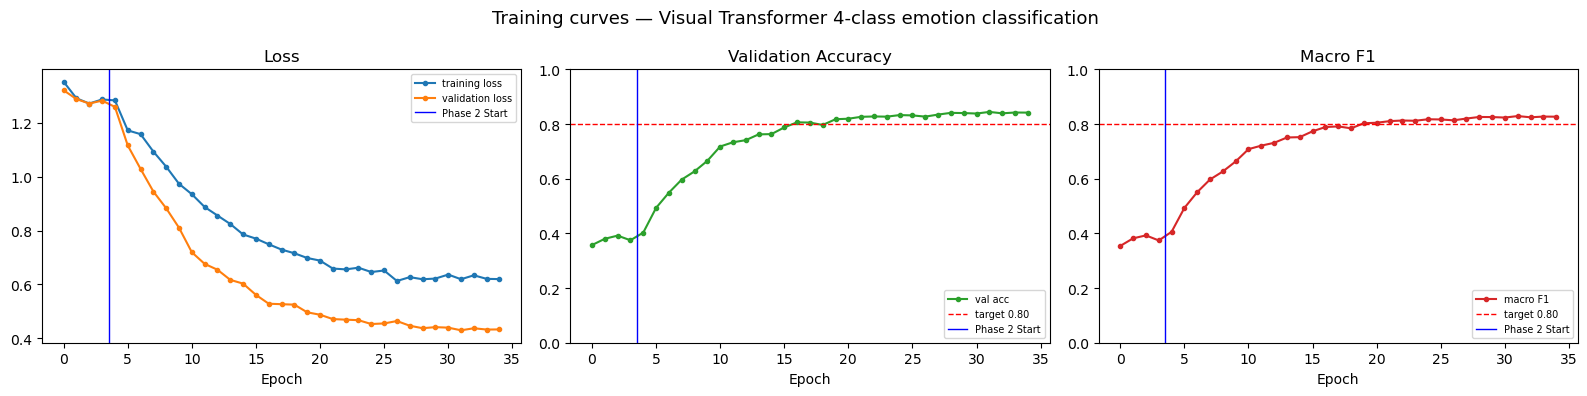

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

#convert logged history to dataframe
df_h = pd.DataFrame(history)

fig, axes = plt.subplots(1, 3, figsize = (16, 4))

#plot training and validation loss curves
ax = axes[0]
ax.plot(df_h["epoch"], df_h["train_loss"], label = "training loss", marker = "o", ms = 3)
ax.plot(df_h["epoch"], df_h["val_loss"],   label = "validation loss",   marker = "o", ms = 3)
ax.axvline(3.5, color = "blue", ls = "-", lw = 1, label = "Phase 2 Start")
ax.set_title("Loss")
ax.set_xlabel("Epoch")
ax.legend(fontsize = 7)
ax.grid(False)

#plot validation accuracy
ax = axes[1]
ax.plot(df_h["epoch"], df_h["val_acc"], color = "C2", marker = "o", ms = 3, label = "val acc")
ax.axhline(0.80, color = "red", ls = "--", lw = 1, label = "target 0.80")
ax.axvline(3.5, color = "blue", ls = "-", lw = 1, label = "Phase 2 Start")
ax.set_title("Validation Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylim(0, 1)
ax.legend(fontsize = 7, loc = "lower right")
ax.grid(False)

#plot macro f1
ax = axes[2]
ax.plot(df_h["epoch"], df_h["macro_f1"], color = "C3", marker = "o", ms = 3, label = "macro F1")
ax.axhline(0.8, color = "red", ls = "--", lw = 1, label = "target 0.80")
ax.axvline(3.5, color = "blue", ls = "-", lw = 1, label = "Phase 2 Start")
ax.set_title("Macro F1")
ax.set_xlabel("Epoch")
ax.set_ylim(0, 1)
ax.legend(fontsize = 7, loc = "lower right")
ax.grid(False)

fig.suptitle("Training curves — Visual Transformer 4-class emotion classification", fontsize = 13)
plt.tight_layout()
plt.savefig("/home/simon/Documents/Zwischen Wörtern und Pixeln/caer-s_4cluster_swin-base_training-curves.svg")
plt.show()

#save history
df_h.to_csv("training_caer-s_4cluster_swin-base_history.csv",
           index = False)


## 8. Final Evaluation on Best Checkpoint

BEST CHECKPOINT — validation results
Val loss  : 0.4292
Val acc   : 0.8442
Macro F1  : 0.8291

              precision    recall  f1-score   support

  Optimistic      0.820     0.845     0.832      2000
 Pessimistic      0.925     0.869     0.896      4000
     Hostile      0.882     0.853     0.867      4000
     Neutral      0.671     0.778     0.721      2000

    accuracy                          0.844     12000
   macro avg      0.825     0.836     0.829     12000
weighted avg      0.851     0.844     0.847     12000



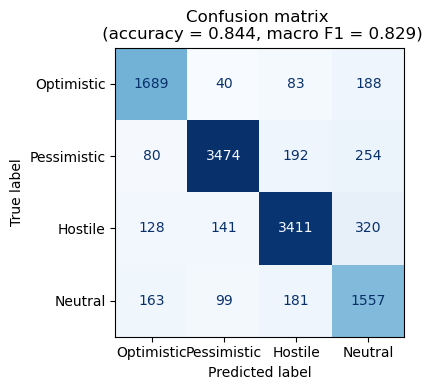

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model.load_state_dict(torch.load("SWIN-Base_checkpoint_35epochs_good-results.pth", map_location = cfg.device)) #change name of file if necessary
val_loss, val_acc, macro_f1, pcl, report = validate(model, val_loader, criterion, cfg)

#print performance metrics
print("=" * 55)
print("BEST CHECKPOINT — validation results")
print("=" * 55)
print(f"Val loss  : {val_loss:.4f}")
print(f"Val acc   : {val_acc:.4f}")
print(f"Macro F1  : {macro_f1:.4f}")
print()
print(report)

@torch.no_grad()
def get_all_preds(model, loader, cfg):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        preds = model(images.to(cfg.device)).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
    return all_labels, all_preds

all_labels, all_preds = get_all_preds(model, val_loader, cfg)
cm = confusion_matrix(all_labels, all_preds)

#plot confusion matrix
fig, ax = plt.subplots(figsize = (5, 4))
ConfusionMatrixDisplay(cm, display_labels = EMOTION_NAMES).plot(
    ax = ax, colorbar = False, cmap = "Blues"
)
ax.set_title(f"Confusion matrix \n (accuracy = {val_acc:.3f}, macro F1 = {macro_f1:.3f})")
plt.tight_layout()
plt.savefig("/home/simon/Documents/Zwischen Wörtern und Pixeln/caer-s_4cluster_swin-base_confusion-matrix.svg")
plt.show()
